# Introduction to the Variational Quantum Eigensolver
A fundamental quantity in quantum physics is the expectation value of a Hamiltonian operator $H$ and a quantum state $\ket{\Psi}$ which is defined as the average energy of the state $\ket{\Psi}$ with the expression

$$E =  \bra{\Psi}H\ket{\Psi}$$ 

An energy can be computed for any state, but it is often of greatest interest to determine the energy of a particular state, the **ground state**.  The ground state is the state which minimizes $ \bra{\Psi}H\ket{\Psi}$ and is thus, determined by the structure of $H$.

Why does the ground state matter?  For contexts like chemistry, the ground state energy of a molecule provides a wealth of knowledge about its reactivity and chemical properties. For quantum computing more broadly, non-physics optimization problems can often be mapped to a Hamiltonian. The ground state of such a Hamiltonian, if obtained, can be sampled to produce high-quality solutions to the original optimization problem.  

<figure>
  <img src="pes.png" alt="plot" width="600">
  <figcaption>Accurate ground state energies are necessary to compute the strength of a chemical bond and other important properties. </figcaption>
</figure>

Finding and constructing the ground state in order to sample from and obtain expectation values is an incredible challenge. Consider an arbitrary quantum state constructed from $N$ qubits which is defined by a $2^N$ state vector of complex entries called amplitudes.  These amplitudes can take any complex value as long as they remain normalized.  

$$
|\psi\rangle =
\begin{pmatrix}
\alpha_0 \\
\alpha_1 \\
\vdots \\
\alpha_{2^n-1}
\end{pmatrix}
\qquad
\text{with} \qquad
\sum_{k=0}^{2^n-1} |\alpha_k|^2 = 1
$$

The first issue arises from the exponential size of the quantum state.  Even if one knows all parameters of a given ground state exactly, it is impossible to store a complete state vector for systems of just over 50 qubits, even if we could pool the memory of every supercomputer in the world! 

Quantum computing subverts this issue by instead representing quantum states as circuits where a sub-exponential number of gates can be applied to $N$ qubits. See the example below. A 16 element state vector is constructed using only 8 gates applied to 4 qubits.  Constructing the same state with just 10 qubits would require a 1024 element state vector but only 20 gates.

<figure>
  <img src="sv.png" alt="plot" width="600">
</figure>

The second issue pertains to actually preparing a ground state with a quantum circuit. There is an infinite number of possible gate combinations and, without any intuition, blindly preparing a ground state circuit might even seem harder than the original problem.  Even in cases like chemistry, where the underlying physics provides some structure to the problem, preparation of the exact ground state may require a prohibitively large number number of gate operations.

Approximate methods are usually required to prepare states that are "close enough" to the true ground state.

## Variational Methods

Thanks to the variational theorem, the search for a circuit that approximates the ground state at least has some guidence. The variational theorem states that for any normalized trial wavefunction $\ket{\Psi_{trial}}$ that

$$\bra{\Psi_{trial}}H\ket{\Psi_{trial}} \ge E_0 $$

Where $E_0$ is the ground state energy. This means that any trial wavefunction will produce an energy that is an upper bound to the ground state energy. In other words, we can try any trial wavefunction and the lowest energy result is the best approximation of the ground state.

This fact has inspired an entire class of quantum algorithms called **variational algorithms** which take advantage of the strengths of both quantum and classical processors working in tandem. The image below depicts the workflow of a general variational algorithm. 


<img src="vqe_image.png" alt="plot" width="900">

1. A predetermined structure or **(ansatz)** of a circuit is chosen where some of the rotation gates are parameterized (${\theta_0 \cdots \theta_n}$).
2. The parameters are then randomly initialized and an expectation value is computed on a quantum computer $\bra{\Psi(\Theta_0)}H\ket{\Psi(\Theta_0)}$.
3. The resulting energy is fed into a classical optimizer which updates the parameters of the circuit to produce  $\ket{\Psi(\Theta_1)}$.
4. The process is repeated until convergence is achieved.


Try the [widget](https://nvidia.github.io/cuda-q-academic/chemistry-simulations/Images/VQE_Widget.html) to explore how this works for the simplest possible case of a single qubit.



It is extremely easy to define variational algorithms with CUDA-Q. A specific example of the **Variational Quantum Eigensolver (VQE)** is shown below for a chemical simulation of the $H_2$ molecule.  First, you can define a parameterized circuit by specifying a custom CUDA-Q kernel or using one of the many chemistry specific ansatze like unitary coupled cluster with singles and double excitations (UCCSD).

In [21]:
import cudaq
from cudaq import spin
import cudaq_solvers as solvers

# Define quantum kernel (ansatz)
@cudaq.kernel
def ansatz(theta: float):
    q = cudaq.qvector(2)
    x(q[0])
    ry(theta, q[1])
    x.ctrl(q[1], q[0])


Next, the Hamiltonian is defined manually below.  Molecular Hamiltonians can also be defined automatically using prebuilt CUDA-Q functions.

In [22]:
# Define Hamiltonian
H = 5.907 - 2.1433 * spin.x(0) * spin.x(1) - \
    2.1433 * spin.y(0) * spin.y(1) + \
    0.21829 * spin.z(0) - 6.125 * spin.z(1)


The last step is to define an optimizer and initial parameters and run the optimization procedure to produce and approximation of the ground state energy. Run the cell below to see the energy of the initial state and the final state following the `vqe` function call.

In [23]:
print(cudaq.draw(ansatz, 0.0))
print(f"Initial state energy: {cudaq.observe(ansatz, H, 0.0).expectation()}")

# Run VQE with defaults (cobyla optimizer)
energy, parameters, data = solvers.vqe(
    lambda thetas: ansatz(thetas[0]),
    H,
    initial_parameters=[0.0],
    verbose=True
)

print(cudaq.draw(ansatz, parameters[0]))
print(f"Ground state energy: {energy}")

       ╭───╮  ╭───╮
q0 : ──┤ x ├──┤ x ├
     ╭─┴───┴─╮╰─┬─╯
q1 : ┤ ry(0) ├──●──
     ╰───────╯     

Initial state energy: -0.4362899999999996
         ╭───╮     ╭───╮
q0 : ────┤ x ├─────┤ x ├
     ╭───┴───┴────╮╰─┬─╯
q1 : ┤ ry(0.5945) ├──●──
     ╰────────────╯     

Ground state energy: -1.7488648829171805


Running this code solves for the `theta` parameter and produces a much lower energy, indicating that the resulting circuit produces a state much closer to the ground state.

## Problems with Variational Algorithms

Despite the ingenuity behind variational algorithms, there are many problems that limit their effectiveness.  One of the most documented is the so-called barren plateau problem.  For even small cases, like the 14-qubit example taken from ["Quantum variational algorithms are swamped with traps"](https://www.nature.com/articles/s41467-022-35364-5) shown below, the loss function landscape is extremely challenging and at problem sizes of even moderate size the landscape usually becomes too flat to optimize. 

 <img src="surface.png" alt="plot" width="900">

We have also assumed evaluation of $\bra{\Psi_{trial}}H\ket{\Psi_{trial}}$ is efficient on a QPU in the sense that it is possible to obtain expectation values for states much larger than ever possible with exact classical methods.  However, the wallclock time to run these on a QPU may be prohibitively slow.  The barren plateau problem means larger molecules require many more steps to converge the energy.  Gradients can help, but are extremely costly to evaluate in their own right.

Consider the image below.  $H_2$ quickly converges as it has only three parameters, but even a small molecule like $N_2$ has 609 parameters and is far from converged after 300 iterations.  Considering the exact energy of these molecules can easily be computed exactly with matrix diagonalization and convergence issues are already becoming apparent means systems that require large number of qubits quickly become prohibitive to solve.

<img src="vqe_molecules.png" alt="plot" width="900">


The code below was used to generate these plots.


UCCSD-VQE energy =   -1.1372816337675324
Number of Variational Parameters = 3


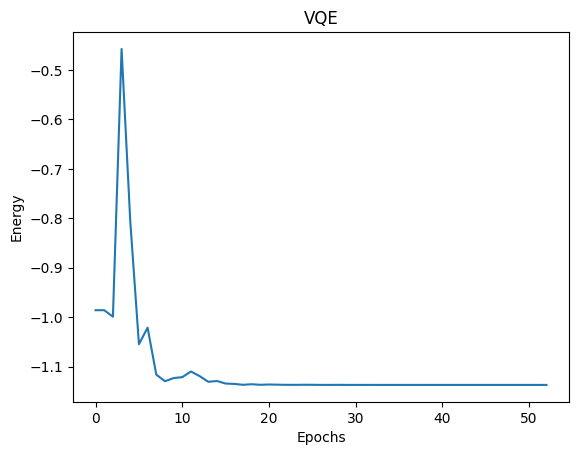

In [1]:
import cudaq, cudaq_solvers as solvers
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Create the molecular hamiltonian
geometry = [('H', (0., 0., 0.)), ('H', (0., 0., 0.74))]
#geometry = [('Li', (0., 0., 0.)), ('H', (0., 0., 1.59))]
#geometry = [('N', (0., 0., 0.)), ('N', (0., 0., 1.10))]
molecule = solvers.create_molecule(geometry, 'sto-3g', 0, 0, CASCI = True)


# Get the number of qubits and electrons
numQubits = molecule.n_orbitals * 2
numElectrons = molecule.n_electrons

spin = 0
initialX = [-.2] * solvers.stateprep.get_num_uccsd_parameters(
    numElectrons, numQubits)


# Define the UCCSD ansatz
@cudaq.kernel
def ansatz(thetas: list[float]):
    q = cudaq.qvector(numQubits)
    for i in range(numElectrons):
        x(q[i])
    solvers.stateprep.uccsd(q, thetas, numElectrons, spin)


def cost(theta):

    exp_val = cudaq.observe(ansatz, molecule.hamiltonian, theta).expectation()

    return exp_val

exp_vals = []


def callback(xk):
    exp_vals.append(cost(xk))


cudaq.set_target('nvidia')
result = minimize(cost,
                  initialX,
                  method='COBYLA',
                  callback=callback,
                  options={'maxiter': 300})

print('UCCSD-VQE energy =  ', result.fun)
print('Number of Variational Parameters =', len(initialX))

plt.plot(exp_vals)
plt.xlabel('Epochs')
plt.ylabel('Energy')
plt.title('VQE')
plt.show()


Another issue is ansatz selection. The quality of the result is limited by how expressive the selected ansatz is. In the case of $H_2$, the ground state can be obtained exactly, because the UCCSD ansatz provides the entanglement needed to match the full configuration interaction (FCI) result. 

This is not true if we select some other ansatz.  The code below entangles adjacent qubits and then applies a parameterized $R_X$, $R_Y$, and $R_Z$ rotation to each.  The optimization converges smoothly, despite having 9 more parameters than UCCSD.  However, the result is off by 0.15 hartree, a significant amount for a chemistry problem. This is because the structure of the custom ansatz is not expressive enough to capture the entanglement necessary to describe the ground state. 

Chemistry provides some good intuition for ansatz selection, but other more general problems lack such structure making ansatz selection a tricky and unclear battle between expressiveness and trainability.

     ╭───╮               ╭───╮╭──────────╮╭──────────╮╭──────────╮
q0 : ┤ x ├──●────────────┤ x ├┤ ry(-0.2) ├┤ rx(-0.2) ├┤ rz(-0.2) ├
     ├───┤╭─┴─╮          ╰─┬─╯├──────────┤├──────────┤├──────────┤
q1 : ┤ x ├┤ x ├──●─────────┼──┤ ry(-0.2) ├┤ rx(-0.2) ├┤ rz(-0.2) ├
     ╰───╯╰───╯╭─┴─╮       │  ├──────────┤├──────────┤├──────────┤
q2 : ──────────┤ x ├──●────┼──┤ ry(-0.2) ├┤ rx(-0.2) ├┤ rz(-0.2) ├
               ╰───╯╭─┴─╮  │  ├──────────┤├──────────┤├──────────┤
q3 : ───────────────┤ x ├──●──┤ ry(-0.2) ├┤ rx(-0.2) ├┤ rz(-0.2) ├
                    ╰───╯     ╰──────────╯╰──────────╯╰──────────╯

Custom Ansatz Energy =   -1.1167591973600985
Number of Variational Parameters = 12


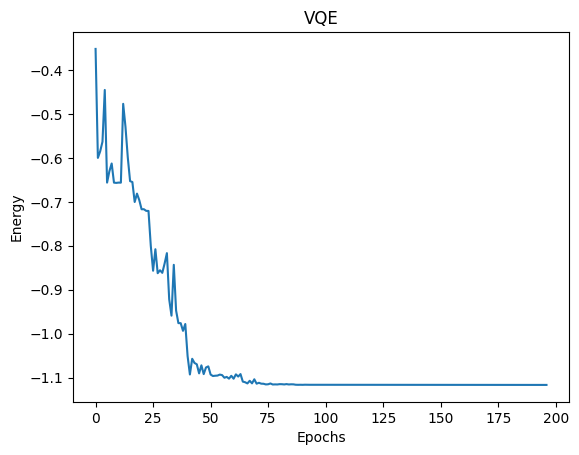

In [12]:
geometry = [('H', (0., 0., 0.)), ('H', (0., 0., 0.74))]

# Get the number of qubits and electrons
numQubits = molecule.n_orbitals * 2
numElectrons = molecule.n_electrons

spin = 0
initialX = [-.2] * 12

@cudaq.kernel
def ansatz(thetas: list[float]):
    q = cudaq.qvector(numQubits)

    x(q[0])
    x(q[1])
    
    for i in range(numQubits):
        x.ctrl(q[i], q[(i+1)%numQubits])

    for i in range(numQubits):
        ry(thetas[i], q[i])

    for i in range(numQubits):
        rx( thetas[i+4], q[i])

    for i in range(numQubits):
        rz(thetas[i+8], q[i])


print(cudaq.draw(ansatz, initialX))
        

def cost(theta):

    exp_val = cudaq.observe(ansatz, molecule.hamiltonian, theta).expectation()

    return exp_val

exp_vals = []


def callback(xk):
    exp_vals.append(cost(xk))

cudaq.set_target('nvidia')
result = minimize(cost,
                  initialX,
                  method='COBYLA',
                  callback=callback,
                  options={'maxiter': 300})

print('Custom Ansatz Energy =  ', result.fun)
print('Number of Variational Parameters =', len(initialX))

plt.plot(exp_vals)
plt.xlabel('Epochs')
plt.ylabel('Energy')
plt.title('VQE')
plt.show()


In summary, variational methods provide a helpful tool for approximating Hamiltonian ground states, but they scale poorly, struggle to converge at moderate problem sizes, and require clever ansatz selection to ensure the result is as good as possible.  Though there are tricks to improve variational methods, their problems warrant exploration of other powerful techniques like AI to efficiently construct ground states for quantum computing applications.  This will be demonstrated with the Generative Quantum Eigensolver.